# CG4002: Voice PyTorch 1D-CNN Trainer & HLS Export

This notebook mirrors the gesture training workflow, but for voice classification.


## 1. Import dependencies & configuration

In [ ]:
# Install required packages (uncomment if needed)
%pip install numpy pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Install PyTorch + Torchaudio + Torchcodec (uncomment if needed)
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.


In [13]:
%pip install pysoundfile

Note: you may need to restart the kernel to use updated packages.


In [16]:
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
import random
import re
import copy

import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

# CONFIGURATION
SAMPLE_RATE = 16000
N_MFCC = 40
TARGET_FRAMES = 50
NUM_CLASSES = 3
BATCH_SIZE = 16
EPOCHS = 60
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
AUGMENT_FACTOR = 3
VAL_SIZE = 0.1
EARLY_STOPPING_PATIENCE = 10
RANDOM_SEED = 42

AUDIO_ROOT = Path('../data/audio')

def get_latest_audio_folder(root: Path) -> Path:
    candidates = []
    for d in root.iterdir():
        if not d.is_dir():
            continue
        if re.fullmatch(r"\d{8}", d.name):
            try:
                dt = datetime.strptime(d.name, "%d%m%Y")
                candidates.append((dt, d))
            except ValueError:
                pass

    if not candidates:
        raise RuntimeError(f'No dated audio folders found under: {root.resolve()}')

    candidates.sort(key=lambda x: x[0])
    return candidates[-1][1]

AUDIO_DIR = get_latest_audio_folder(AUDIO_ROOT)
print(f'Using latest audio folder: {AUDIO_DIR}')

MANIFEST_CSV = AUDIO_DIR / 'voice_manifest.csv'
FEATURES_NPY = AUDIO_DIR / 'voice_features.npy'
LABELS_NPY = AUDIO_DIR / 'voice_labels.npy'
TRAIN_NPY = AUDIO_DIR / 'voice_X_train.npy'
TEST_NPY = AUDIO_DIR / 'voice_X_test.npy'
YTRAIN_NPY = AUDIO_DIR / 'voice_y_train.npy'
YTEST_NPY = AUDIO_DIR / 'voice_y_test.npy'
MEAN_NPY = AUDIO_DIR / 'voice_mean.npy'
STD_NPY = AUDIO_DIR / 'voice_std.npy'
WEIGHTS_H_PATH = AUDIO_DIR / 'voice_cnn_weights.h'

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')



Using latest audio folder: ../data/audio/25022026
Using device: cpu


## 2. Data processing & augmentation

### 2.1 Scan and label raw voice files

In [17]:
# Expected folder layout:
# ../data/audio/
#   class0/
#     *.wav
#   class1/
#     *.wav
#   class2/
#     *.wav

def scan_audio_dataset(root: Path):
    if not root.exists():
        raise FileNotFoundError(f'Audio folder not found: {root.resolve()}')

    class_dirs = sorted([p for p in root.iterdir() if p.is_dir()])
    if len(class_dirs) == 0:
        raise RuntimeError(f'No class subfolders found in: {root.resolve()}')

    class_map = {d.name: i for i, d in enumerate(class_dirs)}

    rows = []
    for class_dir in class_dirs:
        label_id = class_map[class_dir.name]
        for wav in sorted(class_dir.glob('*.wav')):
            rows.append({
                'path': str(wav),
                'label': class_dir.name,
                'label_id': label_id,
            })

    if len(rows) == 0:
        raise RuntimeError('No .wav files found under class folders.')

    manifest = pd.DataFrame(rows)
    return manifest, class_map

manifest_df, CLASS_MAP = scan_audio_dataset(AUDIO_DIR)
manifest_df.to_csv(MANIFEST_CSV, index=False)

print(f'✅ Found {len(manifest_df)} voice samples')
print('Class map:', CLASS_MAP)
print(manifest_df.head())


✅ Found 5714 voice samples
Class map: {'marvin': 0, 'sheila': 1, 'visual': 2}
                                                path   label  label_id
0  ../data/audio/25022026/marvin/00176480_nohash_...  marvin         0
1  ../data/audio/25022026/marvin/00176480_nohash_...  marvin         0
2  ../data/audio/25022026/marvin/00b01445_nohash_...  marvin         0
3  ../data/audio/25022026/marvin/00b01445_nohash_...  marvin         0
4  ../data/audio/25022026/marvin/012187a4_nohash_...  marvin         0


### 2.2 Convert waveform to fixed MFCC windows

In [18]:
mfcc_transform = torchaudio.transforms.MFCC(
    sample_rate=SAMPLE_RATE,
    n_mfcc=N_MFCC,
    melkwargs={
        'n_fft': 512,
        'win_length': 400,
        'hop_length': 160,
        'n_mels': 40,
        'center': True,
        'power': 2.0,
    }
)

def fix_mfcc_time(mfcc_2d, target_frames=TARGET_FRAMES):
    # mfcc_2d: [40, T]
    t = mfcc_2d.shape[1]
    if t == target_frames:
        return mfcc_2d
    if t > target_frames:
        return mfcc_2d[:, :target_frames]
    pad = target_frames - t
    return torch.nn.functional.pad(mfcc_2d, (0, pad), mode='constant', value=0.0)


def load_wav_to_mfcc(path):
    wav, sr = torchaudio.load(path)  # [ch, n]
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if sr != SAMPLE_RATE:
        wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)

    feat = mfcc_transform(wav).squeeze(0)  # [40, T]
    feat = fix_mfcc_time(feat, TARGET_FRAMES)

    # Per-coefficient normalization across time
    mu = feat.mean(dim=1, keepdim=True)
    sd = feat.std(dim=1, keepdim=True).clamp_min(1e-6)
    feat = (feat - mu) / sd

    return feat.numpy().astype(np.float32)


### 2.3 Audio augmentation

In [5]:
%pip install pysoundfile

  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
Using cached pycparser-3.0-py3-none-any.whl (48 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pysoundfile]
Note: you may need to restart the kernel to use updated packages.


In [19]:
import soundfile as sf

def augment_waveform(wav, noise_std=0.003, gain_low=0.85, gain_high=1.15, max_shift_s=0.08):
    # wav shape: [1, N]
    aug = wav.clone()

    # Random gain
    gain = torch.empty(1).uniform_(gain_low, gain_high).item()
    aug = aug * gain

    # Random time shift (+/- max_shift_s)
    max_shift = int(SAMPLE_RATE * max_shift_s)
    if max_shift > 0:
        shift = int(torch.randint(low=-max_shift, high=max_shift + 1, size=(1,)).item())
        aug = torch.roll(aug, shifts=shift, dims=-1)

    # Mild speed perturbation using resample-to-temp-rate then back
    speed = float(torch.empty(1).uniform_(0.95, 1.05).item())
    temp_sr = max(8000, int(SAMPLE_RATE * speed))
    aug = torchaudio.functional.resample(aug, SAMPLE_RATE, temp_sr)
    aug = torchaudio.functional.resample(aug, temp_sr, SAMPLE_RATE)

    # Ensure fixed length after speed perturbation
    if aug.shape[-1] < wav.shape[-1]:
        pad = wav.shape[-1] - aug.shape[-1]
        aug = torch.nn.functional.pad(aug, (0, pad))
    elif aug.shape[-1] > wav.shape[-1]:
        aug = aug[..., :wav.shape[-1]]

    # Additive gaussian noise
    noise = torch.randn_like(aug) * noise_std
    aug = aug + noise

    return aug.clamp(-1.0, 1.0)

def load_waveform_mono_resampled(wav_path):
    audio, sr = sf.read(str(Path(wav_path).resolve()), dtype="float32")
    wav = torch.from_numpy(audio).T if audio.ndim == 2 else torch.from_numpy(audio).unsqueeze(0)

    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if sr != SAMPLE_RATE:
        wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)
    return wav

def waveform_to_feature(wav):
    feat = mfcc_transform(wav).squeeze(0)
    feat = fix_mfcc_time(feat, TARGET_FRAMES)

    # Per-sample CMVN across time
    mu = feat.mean(dim=1, keepdim=True)
    sd = feat.std(dim=1, keepdim=True).clamp_min(1e-6)
    feat = (feat - mu) / sd
    return feat.numpy().astype(np.float32)

def build_feature_set_from_manifest(df, augment_factor=1):
    all_X = []
    all_y = []

    for _, row in df.iterrows():
        wav = load_waveform_mono_resampled(row['path'])
        label_id = int(row['label_id'])

        versions = [wav]
        for _ in range(max(augment_factor - 1, 0)):
            versions.append(augment_waveform(wav))

        for v in versions:
            all_X.append(waveform_to_feature(v))
            all_y.append(label_id)

    X = np.stack(all_X, axis=0)
    y = np.array(all_y, dtype=np.int64)
    return X, y

# Optional snapshot of base (no augmentation) features for debugging/analysis.
X_base, y_base = build_feature_set_from_manifest(manifest_df, augment_factor=1)
np.save(FEATURES_NPY, X_base)
np.save(LABELS_NPY, y_base)

print('✅ Base features generated (no augmentation)')
print('X_base shape:', X_base.shape)
print('y_base shape:', y_base.shape)
print('Class counts:', {int(i): int((y_base == i).sum()) for i in np.unique(y_base)})



✅ Base features generated (no augmentation)
X_base shape: (5714, 40, 50)
y_base shape: (5714,)
Class counts: {0: 2100, 1: 2022, 2: 1592}


## 3. Model definition & training

In [20]:
# Split at original-sample level first (avoid leakage from augmented twins).
idx = np.arange(len(manifest_df))
labels = manifest_df['label_id'].to_numpy(dtype=np.int64)

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=labels,
)

# Hold out validation from train split for early stopping / LR scheduling.
train_idx_inner, val_idx = train_test_split(
    train_idx,
    test_size=VAL_SIZE,
    random_state=RANDOM_SEED,
    stratify=labels[train_idx],
)

# Fast path switch: if split files already exist, reuse them.
REUSE_SPLIT_IF_AVAILABLE = True

# Feature-level augmentation (fast): operates directly on [40, 50] MFCC tensors.
def augment_feature_np(feat, noise_std=0.02, max_time_shift=3, time_mask_max=6, freq_mask_max=4):
    x = feat.copy()

    # Small additive feature noise
    x += np.random.normal(0.0, noise_std, size=x.shape).astype(np.float32)

    # Time shift (cyclic roll along frame axis)
    if max_time_shift > 0:
        shift = int(np.random.randint(-max_time_shift, max_time_shift + 1))
        x = np.roll(x, shift=shift, axis=1)

    # Time mask
    if time_mask_max > 0:
        w = int(np.random.randint(0, time_mask_max + 1))
        if w > 0 and w < x.shape[1]:
            t0 = int(np.random.randint(0, x.shape[1] - w + 1))
            x[:, t0:t0 + w] = 0.0

    # Frequency mask
    if freq_mask_max > 0:
        w = int(np.random.randint(0, freq_mask_max + 1))
        if w > 0 and w < x.shape[0]:
            f0 = int(np.random.randint(0, x.shape[0] - w + 1))
            x[f0:f0 + w, :] = 0.0

    return x.astype(np.float32)

def build_train_from_base_with_feature_aug(X_seed, y_seed, augment_factor):
    feats = [X_seed.astype(np.float32)]
    labels = [y_seed.astype(np.int64)]

    for _ in range(max(augment_factor - 1, 0)):
        aug = np.stack([augment_feature_np(f) for f in X_seed], axis=0)
        feats.append(aug)
        labels.append(y_seed.astype(np.int64))

    X_out = np.concatenate(feats, axis=0)
    y_out = np.concatenate(labels, axis=0)
    return X_out, y_out

if REUSE_SPLIT_IF_AVAILABLE and TRAIN_NPY.exists() and TEST_NPY.exists() and YTRAIN_NPY.exists() and YTEST_NPY.exists() and MEAN_NPY.exists() and STD_NPY.exists():
    X_train = np.load(TRAIN_NPY).astype(np.float32)
    X_test = np.load(TEST_NPY).astype(np.float32)
    y_train = np.load(YTRAIN_NPY).astype(np.int64)
    y_test = np.load(YTEST_NPY).astype(np.int64)

    # Rebuild val quickly from base features + saved train normalization
    train_mean = np.load(MEAN_NPY).astype(np.float32).reshape(1, N_MFCC, 1)
    train_std = np.load(STD_NPY).astype(np.float32).reshape(1, N_MFCC, 1)

    X_val = X_base[val_idx].astype(np.float32)
    y_val = y_base[val_idx].astype(np.int64)
    X_val = (X_val - train_mean) / train_std

    print('✅ Reused cached train/test split from disk (fast path).')
else:
    # Build train set from base features only, then augment in feature domain (fast).
    X_seed = X_base[train_idx_inner].astype(np.float32)
    y_seed = y_base[train_idx_inner].astype(np.int64)
    X_train, y_train = build_train_from_base_with_feature_aug(X_seed, y_seed, AUGMENT_FACTOR)

    # Val/test are clean base features (no augmentation).
    X_val = X_base[val_idx].astype(np.float32)
    y_val = y_base[val_idx].astype(np.int64)
    X_test = X_base[test_idx].astype(np.float32)
    y_test = y_base[test_idx].astype(np.int64)

    # Dataset-level normalization (fit on train only)
    train_mean = X_train.mean(axis=(0, 2), keepdims=True)  # [1,40,1]
    train_std = X_train.std(axis=(0, 2), keepdims=True) + 1e-6

    X_train = (X_train - train_mean) / train_std
    X_val = (X_val - train_mean) / train_std
    X_test = (X_test - train_mean) / train_std

    # Save normalization (flatten to 40 for deployment convenience)
    np.save(MEAN_NPY, train_mean.reshape(-1).astype(np.float32))
    np.save(STD_NPY, train_std.reshape(-1).astype(np.float32))

    np.save(TRAIN_NPY, X_train)
    np.save(TEST_NPY, X_test)
    np.save(YTRAIN_NPY, y_train)
    np.save(YTEST_NPY, y_test)

print(f'Shapes: X_train={X_train.shape}, X_val={X_val.shape}, X_test={X_test.shape}')
print(f'Saved train/test split and mean/std to: {AUDIO_DIR}')

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)



Shapes: X_train=(12339, 40, 50), X_val=(458, 40, 50), X_test=(1143, 40, 50)
Saved train/test split and mean/std to: ../data/audio/25022026


### 3.2 Model Architecture

In [21]:
class VoiceCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(VoiceCNN, self).__init__()

        # Input: [B, 40, 50]
        self.conv1 = nn.Conv1d(in_channels=40, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)  # 50 -> 25

        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.AdaptiveAvgPool1d(1)      # 25 -> 1

        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.squeeze(-1)  # [B, 32]
        x = self.fc(x)     # [B, C]
        return x

class VoiceCNN_Small(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, c1=12, c2=16):
        super().__init__()
        # Input: [B, 40, 50]
        self.conv1 = nn.Conv1d(40, c1, kernel_size=3, padding=1, bias=True)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool1d(kernel_size=2)   # 50 -> 25

        self.conv2 = nn.Conv1d(c1, c2, kernel_size=3, padding=1, bias=True)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.AdaptiveAvgPool1d(1)       # 25 -> 1

        self.fc = nn.Linear(c2, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))  # [B, c1, 25]
        x = self.pool2(self.relu2(self.conv2(x)))  # [B, c2, 1]
        x = x.squeeze(-1)                          # [B, c2]
        x = self.fc(x)                             # [B, C]
        return x

model = VoiceCNN(NUM_CLASSES).to(device)
print(f'✅ Model Initialized on {device}')
print(model)


✅ Model Initialized on cpu
VoiceCNN(
  (conv1): Conv1d(40, 16, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu1): ReLU()
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu2): ReLU()
  (pool2): AdaptiveAvgPool1d(output_size=1)
  (fc): Linear(in_features=32, out_features=3, bias=True)
)


### 3.3 Training Loop

🚀 Starting training for 60 epochs...
Epoch 1/60 | Loss: 0.6147 | Train Acc: 74.3% | Val Acc: 83.8% | LR: 0.001000
Epoch 5/60 | Loss: 0.2767 | Train Acc: 89.2% | Val Acc: 87.3% | LR: 0.001000
Epoch 10/60 | Loss: 0.1889 | Train Acc: 93.0% | Val Acc: 87.3% | LR: 0.001000
Epoch 15/60 | Loss: 0.1401 | Train Acc: 95.0% | Val Acc: 87.8% | LR: 0.001000
Epoch 20/60 | Loss: 0.1217 | Train Acc: 95.9% | Val Acc: 88.4% | LR: 0.001000
Epoch 25/60 | Loss: 0.0822 | Train Acc: 97.6% | Val Acc: 88.2% | LR: 0.000500
⏹️ Early stopping at epoch 27 (best val acc: 88.86%)
✅ Training Complete. Best checkpoint restored.
Final Test Accuracy (float): 85.74%
Final Test Accuracy (Q8.8-sim): 85.74%
              precision    recall  f1-score   support

           0     0.8700    0.8762    0.8731       420
           1     0.8341    0.9185    0.8743       405
           2     0.8759    0.7547    0.8108       318

    accuracy                         0.8574      1143
   macro avg     0.8600    0.8498    0.8527      1

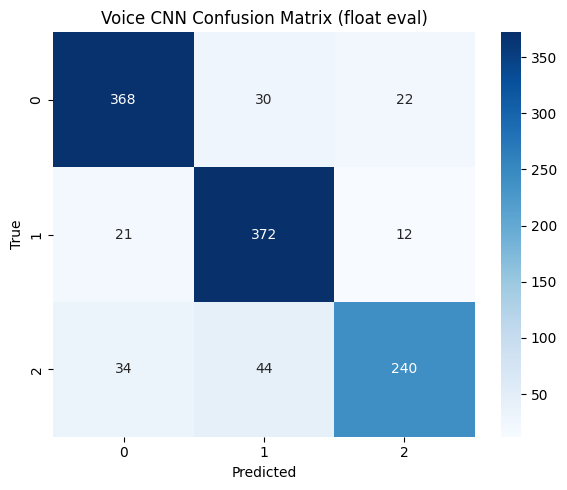

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
)

def evaluate_loader(model, loader, quantize_q88=False):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in loader:
            x = inputs
            if quantize_q88:
                # Simulate signed Q8.8 input path used in deployment.
                x = torch.clamp(torch.round(x * 256.0), -32768, 32767) / 256.0

            outputs = model(x)
            predicted = torch.argmax(outputs, dim=1)

            y_true.extend(labels.detach().cpu().numpy().tolist())
            y_pred.extend(predicted.detach().cpu().numpy().tolist())

    acc = 100.0 * accuracy_score(y_true, y_pred)
    return acc, y_true, y_pred

print(f'🚀 Starting training for {EPOCHS} epochs...')

best_val_acc = -1.0
best_state = copy.deepcopy(model.state_dict())
early_stop_counter = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predicted = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100.0 * correct / max(total, 1)
    avg_loss = running_loss / max(len(train_loader), 1)

    val_acc, _, _ = evaluate_loader(model, val_loader, quantize_q88=False)
    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(
            f'Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | '
            f'Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}% | LR: {current_lr:.6f}'
        )

    if early_stop_counter >= EARLY_STOPPING_PATIENCE:
        print(f'⏹️ Early stopping at epoch {epoch+1} (best val acc: {best_val_acc:.2f}%)')
        break

# Restore best validation checkpoint before final test report/export.
model.load_state_dict(best_state)
print('✅ Training Complete. Best checkpoint restored.')

float_acc, y_true, y_pred = evaluate_loader(model, test_loader, quantize_q88=False)
q88_acc, y_true_q, y_pred_q = evaluate_loader(model, test_loader, quantize_q88=True)

print(f'Final Test Accuracy (float): {float_acc:.2f}%')
print(f'Final Test Accuracy (Q8.8-sim): {q88_acc:.2f}%')
print(classification_report(y_true, y_pred, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Voice CNN Confusion Matrix (float eval)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()



## 4. Export to C++ Header (`voice_cnn_weights.h`)
This extracts trained parameters from `model.state_dict()` and formats them for HLS code.

In [22]:
def export_pytorch_weights(model, filename=WEIGHTS_H_PATH, fuse_input_norm=False, norm_mean=None, norm_std=None):
    print(f'Exporting weights to {filename}...')

    params = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if fuse_input_norm:
        if norm_mean is None or norm_std is None:
            raise ValueError('norm_mean and norm_std are required when fuse_input_norm=True')

        conv_w_key = 'conv1.weight'
        conv_b_key = 'conv1.bias'
        if conv_w_key not in params or conv_b_key not in params:
            raise KeyError('conv1 weights/bias not found in model state_dict')

        mean_t = torch.as_tensor(norm_mean, dtype=params[conv_w_key].dtype)
        std_t = torch.as_tensor(norm_std, dtype=params[conv_w_key].dtype)

        in_ch = params[conv_w_key].shape[1]
        if mean_t.numel() != in_ch or std_t.numel() != in_ch:
            raise ValueError(f'Expected mean/std with {in_ch} values, got {mean_t.numel()} and {std_t.numel()}')
        if torch.any(std_t == 0):
            raise ValueError('std contains zero; cannot fuse normalization')

        inv_std = (1.0 / std_t).view(1, -1, 1)
        params[conv_w_key] = params[conv_w_key] * inv_std

        # bias' = bias - sum_{c,k}(W/std * mean)
        bias_shift = (params[conv_w_key] * mean_t.view(1, -1, 1)).sum(dim=(1, 2))
        params[conv_b_key] = params[conv_b_key] - bias_shift

        print('Fused z-score normalization into conv1 for raw-input inference.')

    filename = Path(filename)
    with open(filename, 'w') as f:
        f.write('#ifndef VOICE_CNN_WEIGHTS_H\n#define VOICE_CNN_WEIGHTS_H\n\n')
        f.write('#include "voice_typedefs.h"\n\n')

        total_params = 0
        for name, tensor in params.items():
            clean_name = name.replace('.', '_').replace('weight', 'w').replace('bias', 'b')
            data = tensor.numpy().flatten()
            size = len(data)
            total_params += size

            print(f'Processing {name} -> {clean_name} ({size} elements)')

            f.write(f'// PyTorch Layer: {name} (Shape: {tuple(tensor.shape)})\n')
            f.write(f'static const data_t {clean_name}[{size}] = {{\n')

            for i, val in enumerate(data):
                f.write(f'{val:.6f}')
                if i < size - 1:
                    f.write(', ')
                if (i + 1) % 10 == 0:
                    f.write('\n    ')
            f.write('\n};\n\n')

        f.write('#endif // VOICE_CNN_WEIGHTS_H\n')

    print(f'\nDone! Total parameters: {total_params}')
    print(f"File saved as '{filename}'. Upload this to Vitis HLS.")


export_pytorch_weights(
    model,
    WEIGHTS_H_PATH,
    fuse_input_norm=True,
    norm_mean=np.load(MEAN_NPY),
    norm_std=np.load(STD_NPY),
)


Exporting weights to ..\data\audio\18022026\voice_cnn_weights.h...
Fused z-score normalization into conv1 for raw-input inference.
Processing conv1.weight -> conv1_w (1440 elements)
Processing conv1.bias -> conv1_b (12 elements)
Processing conv2.weight -> conv2_w (576 elements)
Processing conv2.bias -> conv2_b (16 elements)
Processing fc.weight -> fc_w (48 elements)
Processing fc.bias -> fc_b (3 elements)

Done! Total parameters: 2095
File saved as '..\data\audio\18022026\voice_cnn_weights.h'. Upload this to Vitis HLS.


In [23]:
# Inspect failed cases for audio classification
import IPython.display as ipd

# Find misclassified indices
misclassified = [i for i, (yt, yp) in enumerate(zip(y_true, y_pred)) if yt != yp]
print(f"Number of misclassified samples: {len(misclassified)}")

# Build id-to-label mapping if available
id_to_label = None
if 'CLASS_MAP' in globals():
    id_to_label = {v: k for k, v in CLASS_MAP.items()}

# Show a few failed cases
num_to_show = min(5, len(misclassified))
for idx in misclassified[:num_to_show]:
    true_label = y_true[idx]
    pred_label = y_pred[idx]
    true_word = id_to_label[true_label] if id_to_label and true_label in id_to_label else true_label
    pred_word = id_to_label[pred_label] if id_to_label and pred_label in id_to_label else pred_label
    print(f"Sample idx: {idx} | True: {true_word} | Pred: {pred_word}")
    # Find the original manifest row (if available)
    if 'manifest_df' in globals():
        # Each sample may have been augmented, so try to map back
        # Here, we assume manifest_df is in the same order as the original y
        # If augmentation was used, this may not be exact
        print(manifest_df.iloc[idx])
    # Optionally, play the audio if the path is available
    if 'manifest_df' in globals() and 'path' in manifest_df.columns:
        audio_path = manifest_df.iloc[idx]['path']
        try:
            display(ipd.Audio(audio_path, rate=SAMPLE_RATE))
        except Exception as e:
            print(f"Could not play audio: {e}")
    print("-"*40)


Number of misclassified samples: 163
Sample idx: 17 | True: visual | Pred: sheila
path        ../data/audio/25022026/marvin/01b4757a_nohash_...
label                                                  marvin
label_id                                                    0
Name: 17, dtype: object


----------------------------------------
Sample idx: 39 | True: sheila | Pred: marvin
path        ../data/audio/25022026/marvin/03cf93b1_nohash_...
label                                                  marvin
label_id                                                    0
Name: 39, dtype: object


----------------------------------------
Sample idx: 43 | True: visual | Pred: marvin
path        ../data/audio/25022026/marvin/042a8dde_nohash_...
label                                                  marvin
label_id                                                    0
Name: 43, dtype: object


----------------------------------------
Sample idx: 46 | True: marvin | Pred: sheila
path        ../data/audio/25022026/marvin/0447d7c1_nohash_...
label                                                  marvin
label_id                                                    0
Name: 46, dtype: object


----------------------------------------
Sample idx: 50 | True: sheila | Pred: visual
path        ../data/audio/25022026/marvin/0585b66d_nohash_...
label                                                  marvin
label_id                                                    0
Name: 50, dtype: object


----------------------------------------
